* * *
## Libraries & Modules

In [5]:
import os
import sys
import importlib

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [6]:
import modules.data_path as path_file
import modules.GemNet as gem_net

importlib.reload(path_file)
importlib.reload(gem_net)

from modules.data_path import *
from modules.GemNet import *

***
## **Load *Train* and *Validation* Datasets**

In [7]:
train_dataset_path = 'data/is2res_train_val_test_lmdbs/data/is2re/100k/train/data.lmdb'
val_dataset_path = 'data/is2res_train_val_test_lmdbs/data/is2re/all/val_id/data.lmdb'

train_dataset = resolve_dataset_path(train_dataset_path)
val_dataset = resolve_dataset_path(val_dataset_path)

***
## **GemNet-OC - Train**
### 

In [10]:
g_model, g_train_maes, g_val_maes, g_val_loader, g_device, g_preds, g_targets = configure_and_run_gemnet_training(
    train_data_path=train_dataset, 
    val_data_path=val_dataset, 
    epochs=40, 
    batch_size=32, 
    lr=0.0005
)

Using device: cuda
Starting GemNet-OC training for 40 epochs...
Epoch 001/40 | Train MAE: 4.2451 eV | Val MAE: 1.0831 eV
Epoch 002/40 | Train MAE: 0.9917 eV | Val MAE: 0.9486 eV
Epoch 003/40 | Train MAE: 0.9339 eV | Val MAE: 0.9505 eV
Epoch 004/40 | Train MAE: 0.9202 eV | Val MAE: 0.8599 eV
Epoch 005/40 | Train MAE: 0.8541 eV | Val MAE: 0.8741 eV
Epoch 006/40 | Train MAE: 0.8221 eV | Val MAE: 0.8372 eV
Epoch 007/40 | Train MAE: 0.7853 eV | Val MAE: 0.7877 eV
Epoch 008/40 | Train MAE: 0.7588 eV | Val MAE: 0.7799 eV
Epoch 009/40 | Train MAE: 0.7385 eV | Val MAE: 0.7651 eV
Epoch 010/40 | Train MAE: 0.7245 eV | Val MAE: 0.7526 eV
Epoch 011/40 | Train MAE: 0.8979 eV | Val MAE: 0.8752 eV
Epoch 012/40 | Train MAE: 0.8195 eV | Val MAE: 0.8037 eV
Epoch 013/40 | Train MAE: 1.0779 eV | Val MAE: 0.8084 eV
Epoch 014/40 | Train MAE: 0.7875 eV | Val MAE: 0.8000 eV
Epoch 015/40 | Train MAE: 0.7818 eV | Val MAE: 0.7600 eV
Epoch 016/40 | Train MAE: 0.7620 eV | Val MAE: 0.7615 eV
Epoch 017/40 | Train MAE

In [11]:
import modules.results as results
importlib.reload(results)
from modules.results import *

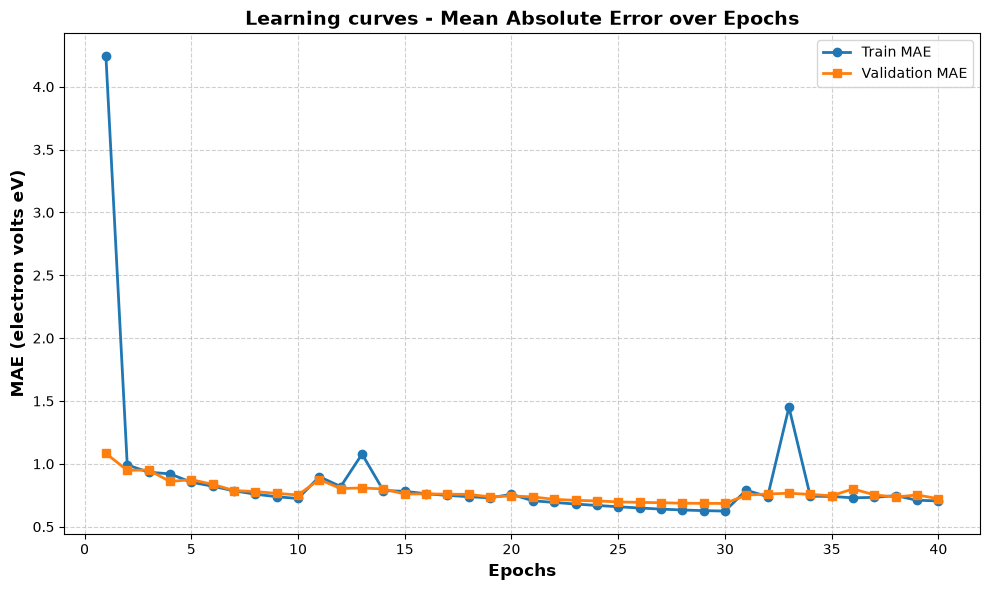

In [12]:
plot_training_curves(g_train_maes, g_val_maes)

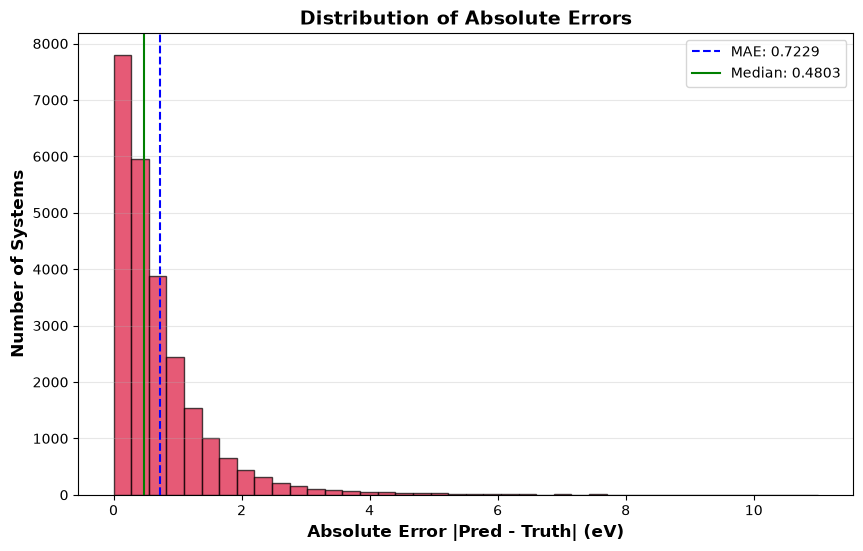

In [13]:
plot_error_distribution(g_preds, g_targets)

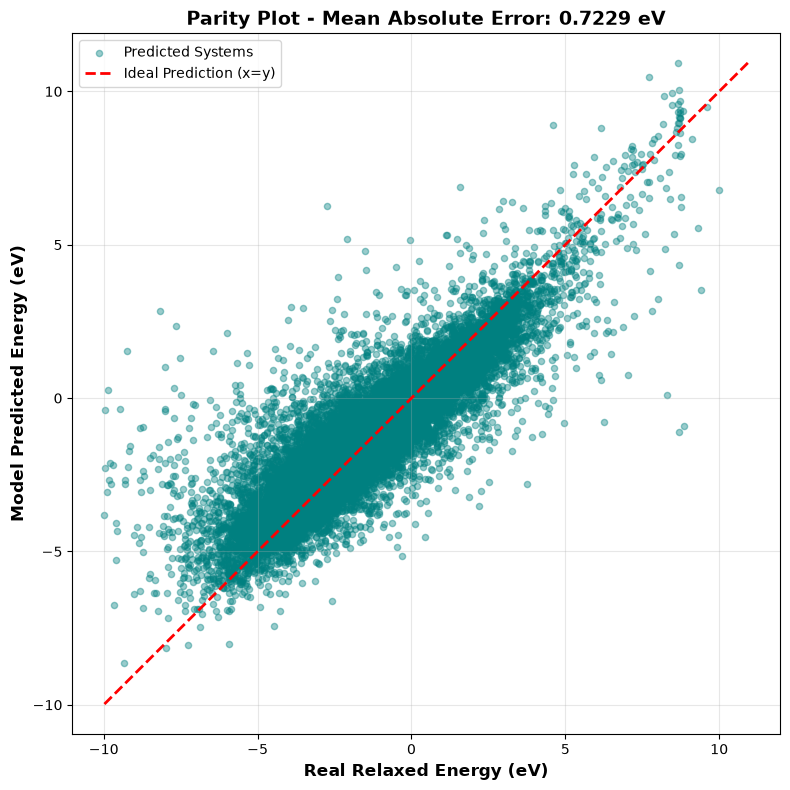

In [14]:
plot_parity_results(g_preds, g_targets)

In [15]:
print_evaluation_table(g_preds, g_targets)


         >> FINAL MODEL EVALUATION RESULTS <<          
| Metric                         | Value              |
|--------------------------------|--------------------|
| Total Systems Evaluated        | 24943              |
| Mean Absolute Error (MAE)      | 0.7229          eV |
| Energy within Threshold (EwT)  | 2.20             % |



In [16]:
import modules.analyze_model as analyze_model
importlib.reload(analyze_model)
from modules.analyze_model import *


sample_batch = next(iter(g_val_loader)).to(g_device)

analyze_stored_model(
    model=g_model,
    sample_batch=sample_batch,
    train_metrics=g_train_maes,
    val_metrics=g_val_maes,
    model_name="GemNet_base"
)

====== Analyzing Model: GemNet_base ======

=== 1. Extracting Weights ===
Total number of weight tensors: 23
  - atom_emb.weight: torch.Size([100, 128])
  - tag_emb.weight: torch.Size([3, 128])
  - distance_expansion.offset: torch.Size([50])
  - interactions.0.mlp.0.weight: torch.Size([128, 178])
  - interactions.0.mlp.0.bias: torch.Size([128])
  ... (truncated for readability)

=== 2. Generating Model Summary ===
Could not generate torchinfo summary due to input format: unsupported operand type(s) for +: 'int' and 'str'

=== 3. Generating Computational Graph Graphic ===
Could not generate graphic: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

=== 4. Writing to TensorBoard at '/home/jepazminoc/h2-catalyst-ml/TensorBoard_logs' ===
  - Retroactively logged 40 epochs of MAE metrics.
TensorBoard writing complete. View with: tensorboard --logdir=/home/jepazminoc/h2-catalyst-ml/TensorBoard_logs

====== Analysis Complete ======

